# IA para Cibersegurança — Aula 6
## Detecção de anomalias, UEBA e SOC assistido (+ mineração de processos)

**Dupla:** `Maria Clara Miranda`  ·  `Evandro José`

> Rodem as células na ordem.

Até agora treinamos modelos **com rótulos** (phishing, ataques). Hoje mudamos a chave: **não temos rótulos**. O objetivo é encontrar **comportamento anômalo** de usuários — a base do **UEBA** (*User and Entity Behavior Analytics*) — e depois **priorizar alertas** pensando no analista do SOC. Fechamos com **mineração de processos**, que acha *sequências* de ações fora do padrão.

Ferramentas: Isolation Forest, LOF e clustering para anomalia; um grafo de processos (directly-follows) para as sequências.

## 0. A base — um log corporativo (estilo CERT)

O *benchmark* clássico de UEBA é o **CERT Insider Threat (CMU)**: logs de logon, dispositivos (USB), arquivos e web por usuário. Mas ele é **sintético mesmo** e pesa 10–22 GB — inviável para baixar em aula. Então **geramos aqui um log equivalente**, com alguns *insiders* plantados.

> Importante: os *insiders* são plantados **só para avaliar no final** se os métodos funcionaram. **Não usamos essa informação para treinar** — no mundo real ela não existe. É exatamente o desafio do não supervisionado.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style='whitegrid')
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def gerar_log(n_users=180, n_insiders=6, dias=30):
    users = [f'U{100+i}' for i in range(n_users)]
    insiders = set(rng.choice(users, n_insiders, replace=False))
    linhas, base = [], datetime(2024, 3, 1)
    for u in users:
        ins = u in insiders
        pc = f'PC{rng.integers(1,60)}'
        for d in range(dias):
            dia = base + timedelta(days=d)
            fds = dia.weekday() >= 5
            if fds and not ins and rng.random() > 0.10: continue   # normal quase não trabalha fim de semana
            if fds and ins and rng.random() > 0.50: continue
            hora = int(rng.choice([22,23,0,1,2,3])) if (ins and rng.random() < 0.45) else int(np.clip(rng.normal(9,1.2),6,19))
            t = dia.replace(hour=hora % 24, minute=int(rng.integers(0,59)))
            linhas.append((u, t, 'logon', pc, 0, ins))
            for _ in range(int(rng.poisson(8) + 2)):
                t = t + timedelta(minutes=int(rng.integers(2,40)))
                if ins and rng.random() < 0.30:                    # atividade de exfiltração
                    a = rng.choice(['usb_connect','file_copy','web_upload'], p=[0.25,0.4,0.35])
                    b = int(rng.normal(5e7,2e7)) if a == 'web_upload' else int(rng.normal(2e6,1e6))
                else:
                    a = rng.choice(['web_browse','file_read','email_send'], p=[0.5,0.35,0.15])
                    if not ins and rng.random() < 0.02:            # ruído: normal às vezes usa USB
                        a = rng.choice(['usb_connect','file_copy'])
                    b = int(abs(rng.normal(2e5,1e5)))
                if rng.random() < 0.2: pc = f'PC{rng.integers(1,60)}'
                linhas.append((u, t, a, pc, max(b,0), ins))
            linhas.append((u, t + timedelta(minutes=int(rng.integers(1,30))), 'logoff', pc, 0, ins))
    df = pd.DataFrame(linhas, columns=['user','timestamp','acao','pc','bytes','is_insider'])
    return df.sort_values('timestamp').reset_index(drop=True)

log = gerar_log()
print('Eventos:', len(log), '| usuários:', log.user.nunique(),
      '| insiders plantados:', int(log.groupby('user')['is_insider'].max().sum()))
log.head()

Eventos: 47520 | usuários: 180 | insiders plantados: 6


,user,timestamp,acao,pc,bytes,is_insider
0,U272,2024-03-01 06:02:00,logon,PC29,0,False
1,U149,2024-03-01 06:08:00,logon,PC4,0,False
2,U162,2024-03-01 06:16:00,logon,PC56,0,False
3,U122,2024-03-01 06:18:00,logon,PC20,0,False
4,U210,2024-03-01 06:24:00,logon,PC56,0,False


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pandas as pd

# # ajuste o caminho se a pasta for outra
# CAMINHO = '/content/drive/MyDrive/ia-ciberseguranca/cert_r42_filtrado.csv'

# log = pd.read_csv(CAMINHO, parse_dates=['timestamp'])
# log['is_insider'] = log['is_insider'].astype(bool)

# # ---- validação da estrutura ----
# print('Dimensões:', log.shape)
# print('Colunas   :', list(log.columns))
# print('Período   :', log['timestamp'].min(), '->', log['timestamp'].max())
# print('Usuários  :', log['user'].nunique(),
#       '| insiders :', int(log.groupby('user')['is_insider'].max().sum()))
# print('\nEventos por ação:')
# print(log['acao'].value_counts().to_string())

# esperado = {'user','timestamp','acao','pc','bytes','is_insider'}
# faltando = esperado - set(log.columns)
# print('\nSchema OK ✅' if not faltando else f'\n⚠️ faltando colunas: {faltando}')

# log.head()

## Parte A — UEBA: perfil de comportamento por usuário

A ideia do UEBA: em vez de olhar evento por evento, **construímos um perfil de cada usuário** (features que resumem seu comportamento) e procuramos quem **foge do padrão do grupo**.

In [ ]:
log['hora'] = log.timestamp.dt.hour
log['fds']  = log.timestamp.dt.weekday >= 5
g = log.groupby('user')

perfil = pd.DataFrame({
    'n_eventos':        g.size(),
    'frac_offhours':    g.apply(lambda x: ((x.hora >= 20) | (x.hora < 6)).mean()),
    'frac_fds':         g['fds'].mean(),
    'n_usb':            g.apply(lambda x: (x.acao == 'usb_connect').sum()),
    'n_file_copy':      g.apply(lambda x: (x.acao == 'file_copy').sum()),
    'n_web_upload':     g.apply(lambda x: (x.acao == 'web_upload').sum()),
    'bytes_out':        g.apply(lambda x: x.loc[x.acao == 'web_upload', 'bytes'].sum()),
    'distinct_pcs':     g['pc'].nunique(),
    'n_distinct_acoes': g['acao'].nunique(),
})
gabarito = g['is_insider'].max()      # guardado SÓ para avaliação no final
print('Perfil (uma linha por usuário):', perfil.shape)
perfil.head()

Perfil (uma linha por usuário): (180, 9)


,n_eventos,frac_offhours,frac_fds,n_usb,n_file_copy,n_web_upload,bytes_out,distinct_pcs,n_distinct_acoes
user,,,,,,,,,
U100,246,0.0,0.024390,2,0,0,0,31,6
U101,231,0.0,0.000000,1,1,0,0,27,7
U102,247,0.0,0.000000,2,5,0,0,30,7
U103,283,0.0,0.127208,4,0,0,0,32,6
U104,230,0.0,0.000000,3,3,0,0,24,7


Vejamos como duas features comportamentais já separam visualmente alguns usuários.

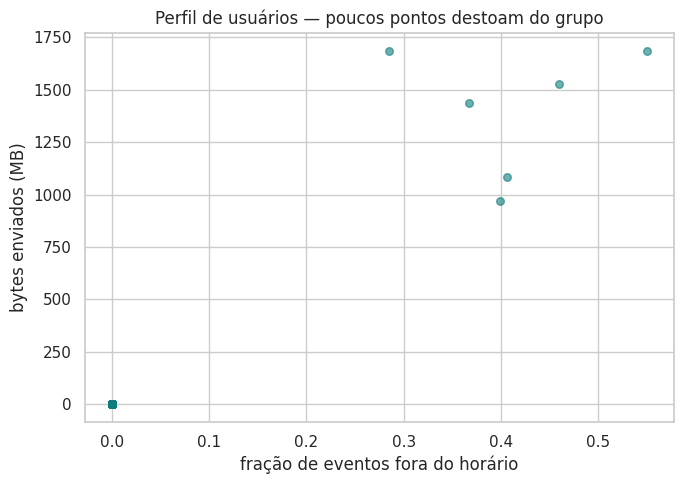

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(perfil['frac_offhours'], perfil['bytes_out']/1e6, s=30, alpha=0.6, color='#0E7C7B')
plt.xlabel('fração de eventos fora do horário'); plt.ylabel('bytes enviados (MB)')
plt.title('Perfil de usuários — poucos pontos destoam do grupo')
plt.tight_layout(); plt.show()

**O que observar:** a maioria fica concentrada num canto (trabalho diurno, pouco upload) e alguns pontos se afastam. Anomalia = estar longe do comportamento típico. Vamos medir isso com três métodos.

### Padronização
Métodos baseados em distância/densidade (LOF) e mesmo o Isolation Forest lidam melhor com features na mesma escala.

In [ ]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(perfil.values)
print('Matriz de perfis padronizada:', X.shape)

Matriz de perfis padronizada: (180, 9)


### Método 1 — Isolation Forest
Isola cada ponto com cortes aleatórios: pontos anômalos são **isolados com poucos cortes**. Devolve um score de anomalia por usuário.

In [ ]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_SEED)
iso.fit(X)
perfil['score_iso'] = -iso.score_samples(X)   # maior = mais anômalo

### Método 2 — LOF (Local Outlier Factor)
Compara a densidade de cada ponto com a dos vizinhos: quem está numa região muito mais “vazia” que os vizinhos é anômalo.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof.fit_predict(X)
perfil['score_lof'] = -lof.negative_outlier_factor_

### Método 3 — Clustering (K-Means)
Agrupamos os perfis e medimos a **distância ao centro mais próximo**: quem está muito longe de qualquer grupo é candidato a anomalia.

In [ ]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_SEED).fit(X)
dist = np.min(km.transform(X), axis=1)
perfil['score_cluster'] = dist

Vamos ver a distribuição dos scores do Isolation Forest e onde fica o corte de alerta.

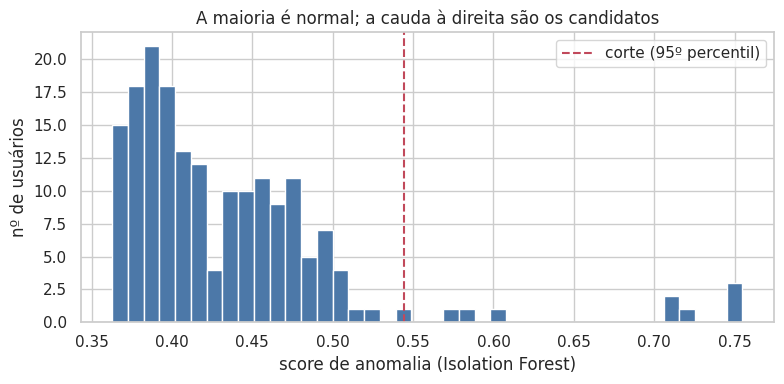

In [ ]:
corte = perfil['score_iso'].quantile(0.95)
plt.figure(figsize=(8,4))
plt.hist(perfil['score_iso'], bins=40, color='#4C78A8')
plt.axvline(corte, ls='--', color='#C1495B', label='corte (95º percentil)')
plt.xlabel('score de anomalia (Isolation Forest)'); plt.ylabel('nº de usuários')
plt.title('A maioria é normal; a cauda à direita são os candidatos'); plt.legend(); plt.tight_layout(); plt.show()

### Os três métodos concordam?
Comparamos quem cada método coloca no topo. Concordância entre métodos aumenta a confiança no alerta.

In [ ]:
topN = 12
tops = {m: set(perfil[m].sort_values(ascending=False).head(topN).index)
        for m in ['score_iso','score_lof','score_cluster']}
consenso = tops['score_iso'] & tops['score_lof'] & tops['score_cluster']
print(f'Top-{topN} de cada método:')
for m, s in tops.items(): print(f'  {m}: {sorted(s)}')
print(f'\nUsuários no topo dos TRÊS métodos (consenso): {sorted(consenso)}')

Top-12 de cada método:
  score_iso: ['U115', 'U158', 'U177', 'U178', 'U181', 'U205', 'U215', 'U226', 'U232', 'U236', 'U241', 'U254']
  score_lof: ['U115', 'U124', 'U143', 'U177', 'U178', 'U181', 'U182', 'U215', 'U232', 'U236', 'U241', 'U254']
  score_cluster: ['U103', 'U115', 'U158', 'U181', 'U182', 'U205', 'U215', 'U226', 'U232', 'U236', 'U241', 'U254']

Usuários no topo dos TRÊS métodos (consenso): ['U115', 'U181', 'U215', 'U232', 'U236', 'U241', 'U254']


### Só agora usamos o gabarito — os métodos funcionaram?
No mundo real não temos essa resposta. Aqui, como plantamos os *insiders*, dá para medir **quantos** aparecem entre os mais anômalos (precision@k).

In [ ]:
def precision_at_k(coluna, k):
    topo = perfil[coluna].sort_values(ascending=False).head(k).index
    return int(gabarito.loc[topo].sum())

total_ins = int(gabarito.sum())
print(f'Insiders plantados: {total_ins}\n')
print(f'{"método":<16}{"top-5":>8}{"top-10":>8}{"top-20":>8}')
for m in ['score_iso','score_lof','score_cluster']:
    print(f'{m:<16}{precision_at_k(m,5):>8}{precision_at_k(m,10):>8}{precision_at_k(m,20):>8}')

Insiders plantados: 6

método             top-5  top-10  top-20
score_iso              5       6       6
score_lof              5       6       6
score_cluster          3       4       6


## Parte B — Priorização de alertas e a fadiga do analista

Um SOC não consegue investigar todo mundo. O score vira uma **fila de alertas**: investiga-se do mais anômalo para o menos. Duas perguntas guiam tudo:
- **Onde cortar?** (quantos alertas por dia o time aguenta)
- **Como ordenar?** (para os casos reais chegarem ao topo)

### Combinando os métodos (ensemble por ranking)
Somar as posições (ranks) dos três métodos costuma ordenar melhor que qualquer um sozinho.

In [ ]:
perfil['rank_ensemble'] = (perfil['score_iso'].rank() +
                           perfil['score_lof'].rank() +
                           perfil['score_cluster'].rank())
fila = perfil.sort_values('rank_ensemble', ascending=False).copy()
fila['is_insider'] = gabarito.loc[fila.index].values

print('FILA DE ALERTAS (top 15) — o SOC investiga de cima para baixo:')
fila[['score_iso','score_lof','score_cluster','is_insider']].head(15).round(2)

FILA DE ALERTAS (top 15) — o SOC investiga de cima para baixo:


,score_iso,score_lof,score_cluster,is_insider
user,,,,
U215,0.75,7.90,3.29,True
U115,0.75,7.21,3.71,True
U254,0.75,7.28,2.72,True
U241,0.58,2.21,3.70,False
U236,0.71,6.63,2.45,True
U158,0.58,1.35,2.57,False
U177,0.72,6.77,2.08,True
U232,0.54,1.41,2.48,False
U178,0.71,7.00,2.05,True


### O trade-off da fadiga de alertas
Se o corte for **frouxo**, muitos alertas — a maioria falso positivo — e o analista se esgota. Se for **apertado**, poucos alertas, mas o risco de deixar um insider passar aumenta.

In [ ]:
for k in [5, 10, 20, 40]:
    achou = precision_at_k('rank_ensemble', k)
    fp = k - achou
    print(f'Investigando top-{k:>2}: pega {achou}/{total_ins} insiders  |  {fp} alarmes falsos  '
          f'|  precisão da fila = {achou/k:.0%}')

Investigando top- 5: pega 4/6 insiders  |  1 alarmes falsos  |  precisão da fila = 80%
Investigando top-10: pega 6/6 insiders  |  4 alarmes falsos  |  precisão da fila = 60%
Investigando top-20: pega 6/6 insiders  |  14 alarmes falsos  |  precisão da fila = 30%
Investigando top-40: pega 6/6 insiders  |  34 alarmes falsos  |  precisão da fila = 15%


**A conversa de SOC:** com este modelo, investigar ~10 usuários/dia já captura a maioria dos insiders com poucos falsos positivos. Baixar o corte para 40 não pega muito mais insiders, mas **quadruplica o trabalho** — é a fadiga de alerta em números. O objetivo do UEBA não é “acertar tudo”, é **colocar os casos certos no topo da fila**.

## Parte C — Mineração de processos: sequências fora do padrão

Até aqui olhamos *quanto* cada usuário faz. Agora olhamos *em que ordem*. Na **mineração de processos**:
- cada **caso** = um usuário num dia;
- o **trace** = a sequência de ações daquele dia (logon → web_browse → file_read → …).

Descobrimos o **fluxo típico** e marcamos os caminhos raros — um `usb_connect → file_copy → web_upload` de madrugada não se parece com o dia a dia de ninguém.

In [ ]:
# Para a mineração de processos: enxugar o excesso de 'web_browse'.
# Mantemos no máximo 3 web_browse seguidos por usuário-dia (o resto é ruído repetido).
log_proc = log.sort_values('timestamp').copy()
log_proc['data'] = log_proc['timestamp'].dt.date

def limita_browse(g, maximo=3):
    eh_browse = g['acao'].eq('web_browse')
    # conta web_browse consecutivos dentro do dia
    grupo = (~eh_browse).cumsum()
    ordem = g.groupby(grupo).cumcount()
    manter = ~eh_browse | (ordem < maximo)
    return g[manter]

log_proc = (log_proc.groupby(['user','data'], group_keys=False)[log_proc.columns]
                    .apply(limita_browse)
                    .reset_index(drop=True))

print('Antes :', len(log), 'eventos')
print('Depois:', len(log_proc), 'eventos (para a mineração de processos)')
print(log_proc['acao'].value_counts().to_string())

Antes : 47520 eventos
Depois: 43844 eventos (para a mineração de processos)
acao
web_browse     15482
file_read      13411
email_send      5748
logon           3980
logoff          3980
file_copy        559
usb_connect      517
web_upload       167


In [ ]:
log_proc['data'] = log.timestamp.dt.date
traces = log_proc.groupby(['user','data'])['acao'].apply(list)

variantes = traces.apply(lambda s: ' > '.join(s)).value_counts()
print(f'Casos (usuário-dia): {len(traces)}  |  variantes distintas: {len(variantes)}\n')
print('Variantes mais comuns (o comportamento "normal"):')
for v, c in variantes.head(3).items():
    print(f'  ({c}x)  {v[:90]}...')

Casos (usuário-dia): 206  |  variantes distintas: 206

Variantes mais comuns (o comportamento "normal"):
  (1x)  logon > file_read > email_send > web_browse > web_browse > file_read > web_browse > web_br...
  (1x)  logon > file_read > web_browse > email_send > file_read > file_read > web_browse > file_re...
  (1x)  logon > web_browse > email_send > email_send > web_browse > email_send > web_browse > emai...


### O grafo de processo (directly-follows)
Contamos quantas vezes cada ação é seguida diretamente por outra. É o “mapa” do processo.

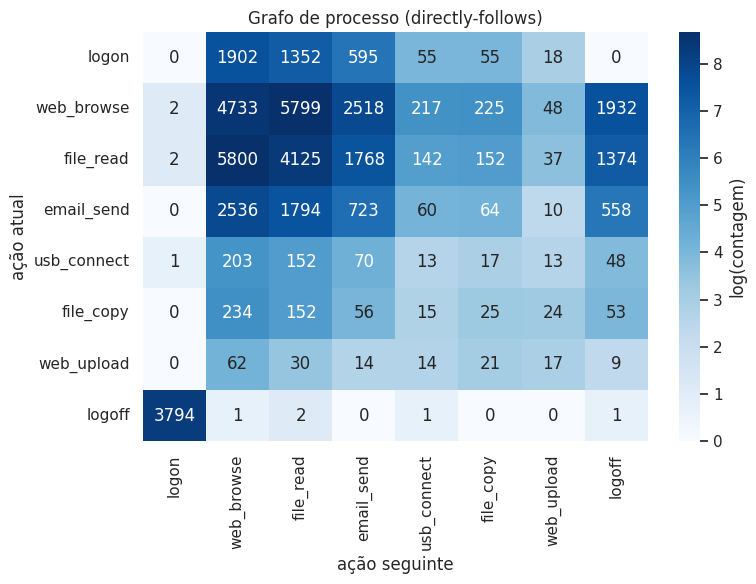

In [ ]:
from collections import Counter
trans = Counter()
for s in traces:
    for a, b in zip(s, s[1:]):
        trans[(a, b)] += 1

acoes = ['logon','web_browse','file_read','email_send','usb_connect','file_copy','web_upload','logoff']
M = pd.DataFrame(0, index=acoes, columns=acoes, dtype=float)
for (a, b), c in trans.items():
    if a in acoes and b in acoes: M.loc[a, b] = c

plt.figure(figsize=(8,6))
sns.heatmap(np.log1p(M), annot=M.astype(int), fmt='d', cmap='Blues', cbar_kws={'label':'log(contagem)'})
plt.xlabel('ação seguinte'); plt.ylabel('ação atual'); plt.title('Grafo de processo (directly-follows)')
plt.tight_layout(); plt.show()

**O que observar:** o fluxo normal (logon → navegação/arquivos → logoff) domina o mapa. As transições que envolvem `usb_connect`, `file_copy` e `web_upload` são raras — e é aí que mora o risco.

### Escore de “surpresa” por caso
Damos a cada caso uma nota pela **raridade das suas transições** (transição rara = muita surpresa). Casos muito surpreendentes são anomalias de processo.

In [ ]:
import math
tot = sum(trans.values())
prob = {k: v/tot for k, v in trans.items()}

def surpresa(seq):
    ps = [prob[(a,b)] for a, b in zip(seq, seq[1:])]
    return float(np.mean([-math.log2(p) for p in ps])) if ps else 0.0

casos = traces.reset_index()
casos['surpresa'] = traces.apply(surpresa).values
casos['is_insider'] = casos['user'].isin(set(log[log.is_insider].user)).values

top_casos = casos.sort_values('surpresa', ascending=False).head(15)
print('Casos (usuário-dia) mais surpreendentes:')
top_casos[['user','data','surpresa','is_insider']].round(2)

Casos (usuário-dia) mais surpreendentes:


,user,data,surpresa,is_insider
133,U215,2024-03-19,6.76,True
177,U254,2024-03-25,6.64,True
18,U115,2024-03-04,6.53,True
90,U178,2024-03-13,6.52,True
155,U236,2024-03-21,6.24,True
89,U177,2024-03-13,6.22,True
149,U230,2024-03-21,4.38,False
9,U108,2024-03-02,4.34,False
131,U213,2024-03-19,4.19,False
197,U272,2024-03-27,4.15,False


### A mineração de processos concorda com o UEBA?

In [ ]:
lim = casos['surpresa'].quantile(0.95)
flag = casos[casos['surpresa'] >= lim]
print(f'Nos 5% de casos mais surpreendentes: {flag.is_insider.mean():.0%} são dias de insider '
      f'(na base toda, apenas {casos.is_insider.mean():.0%}).')
print('Ou seja: olhar a SEQUÊNCIA das ações destaca os mesmos usuários de risco — por um caminho diferente do UEBA.')

Nos 5% de casos mais surpreendentes: 55% são dias de insider (na base toda, apenas 3%).
Ou seja: olhar a SEQUÊNCIA das ações destaca os mesmos usuários de risco — por um caminho diferente do UEBA.


### Por que usar os dois juntos
- **UEBA (features):** pega quem faz *volume/horário* fora do padrão. Pode não ver um ataque “discreto”.
- **Mineração de processos (sequência):** pega *ordens de ação* estranhas, mesmo com volume normal.
- **No SOC:** combinados, cobrem mais tipos de ameaça e ainda **explicam** o alerta (“este usuário fez copy→upload de madrugada”), o que ajuda o analista a decidir rápido.

## Discussão (respondam no notebook)
- Por que **não** usamos o rótulo de insider para treinar? O que muda em relação às aulas anteriores?
- Seu time só investiga 10 alertas/dia. Que corte você usaria e o que aceita perder?
- Cite um ataque que o **UEBA** pegaria e um que só a **mineração de processos** pegaria.
- Que outra feature de comportamento você adicionaria ao perfil de usuário?

### Respostas

**1. Por que não usamos o rótulo de insider para treinar?**

Porque na vida real ninguém te entrega uma coluna dizendo quem é o cara mal-intencionado — se a gente tivesse esse rótulo o problema já estaria resolvido. Nas aulas anteriores a gente treinava um classificador supervisionado (tipo Random Forest) que aprendia direto "isso aqui é ataque, isso aqui não é", olhando exemplos rotulados dos dois lados. Aqui não: o Isolation Forest, o LOF e o KMeans nunca veem a coluna `is_insider` durante o ajuste, só usamos ela lá no fim pra conferir se o que sobrou no topo da fila realmente eram os insiders plantados. Ou seja, o modelo não aprende "o que é malicioso", ele aprende "o que é comportamento normal" e aponta quem foge disso. Isso muda bastante a lógica: em vez de prever uma classe, a gente está medindo distância/densidade/isolamento em relação à maioria.

**2. Corte de 10 alertas/dia — o que aceita perder?**

Pelos números que saíram (top-10 pega os 6 insiders com só 4 falsos positivos, 60% de precisão), o corte de 10 já parece um bom equilíbrio — subir pra 20 ou 40 quase não aumenta a detecção (continua em 6/6) e só joga mais trabalho em cima do analista, com a precisão caindo pra 30% e depois 15%. Então usaria o top-10 mesmo. O que se aceita perder nesse caso é o risco de um insider novo aparecer bem mais "discreto" que os que já foram pegos e acabar ficando na posição 11 ou 12, fora da fila do dia — teria que confiar que ele reapareceria nos próximos dias com comportamento parecido pra ser pego depois.

**3. Um ataque que o UEBA pegaria x um que só a mineração de processos pegaria**

O UEBA (olhando quantidade/volume) pega bem um cara que começa a copiar muito mais arquivo pra USB ou sobe muito mais bytes por upload do que o normal dele — isso aparece direto nas features de contagem, tipo `n_usb`, `n_file_copy` e `bytes_out`.

Já um caso em que a pessoa faz a mesma quantidade de ações de sempre, só que numa ordem esquisita (por exemplo, conectar USB, copiar arquivo e já sair fazendo upload na sequência, sem passar pelo fluxo normal de logon → ler email → navegar → etc.), pode passar batido pro UEBA porque os totais do dia não fogem muito da média. É exatamente esse tipo de caso que a mineração de processos pega, porque ela olha a sequência das ações e não só o quanto de cada uma foi feita.

**4. Outra feature que adicionaria ao perfil**

Uma que acho que faria falta é algo que capture a variação do comportamento do próprio usuário ao longo dos dias, tipo o desvio-padrão do horário de logon ou da quantidade de eventos por dia — hoje o perfil só olha médias/somas do período inteiro, então um usuário que é sempre muito regular e de repente tem um dia totalmente fora do padrão dele mesmo pode não se destacar tanto na comparação com os outros usuários. Outra ideia seria contar quantos PCs diferentes ele usou em um mesmo dia (não só no total), porque logar em várias máquinas em pouco tempo costuma ser sinal de conta comprometida.


---
*Nota: usamos IA (Claude) para organizar e formatar a redação das respostas acima a partir dos resultados que o próprio notebook gerou — fins estéticos e de organização do texto.*

## Checklist do entregável de hoje
- [x] Log de eventos carregado e perfis de usuário construídos (UEBA)
- [x] Anomalias detectadas com Isolation Forest, LOF e clustering
- [x] Limiar calibrado e métodos comparados (precision@k com o gabarito)
- [x] Fila de alertas priorizada + análise da fadiga de alertas
- [x] Mineração de processos: grafo, variantes e escore de surpresa
- [x] Respostas da discussão registradas no notebook

**Próxima aula:** pipeline reprodutível e consolidação — preparação para a AV1.